# Brain Tumor MRI Classification - Model Evaluation

In [1]:
# Imports

from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

In [2]:
# Configuration

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

TEST_DIR = DATA_DIR / "Testing"

MODELS_DIR = PROJECT_ROOT / "models"

REPORTS_DIR = PROJECT_ROOT / "reports"

IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

In [3]:
# Load Model

model = keras.models.load_model(
    MODELS_DIR / "best_model.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
# Load Class Names

with open(MODELS_DIR / "class_names.pkl","rb") as file:
    CLASS_NAMES = pickle.load(file)

NUM_CLASSES = len(CLASS_NAMES)

print(CLASS_NAMES)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
# Load Testing Dataset

test_dataset = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False,

    label_mode="categorical"

)

Found 1600 files belonging to 4 classes.


In [6]:
# Predict Test Dataset

predictions = model.predict(test_dataset)

y_pred = np.argmax(predictions,axis=1)

y_true = np.concatenate(

    [np.argmax(labels,axis=1)

     for images,labels in test_dataset],

    axis=0

)

print("Prediction Completed")

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 385ms/step
Prediction Completed


In [7]:
# Accuracy

accuracy = accuracy_score(

    y_true,

    y_pred

)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8200


In [8]:
# Precision

precision = precision_score(

    y_true,

    y_pred,

    average="weighted"

)

print(f"Precision : {precision:.4f}")

Precision : 0.8230


In [9]:
# Recall

recall = recall_score(

    y_true,

    y_pred,

    average="weighted"

)

print(f"Recall : {recall:.4f}")

Recall : 0.8200


In [10]:
# F1 Score

f1 = f1_score(

    y_true,

    y_pred,

    average="weighted"

)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.8125


In [11]:
# Classification Report

report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES

)

print(report)

              precision    recall  f1-score   support

      glioma       0.85      0.66      0.75       400
  meningioma       0.78      0.65      0.71       400
     notumor       0.90      0.98      0.94       400
   pituitary       0.76      0.99      0.86       400

    accuracy                           0.82      1600
   macro avg       0.82      0.82      0.81      1600
weighted avg       0.82      0.82      0.81      1600



In [12]:
# Save Classification Report

report_path = REPORTS_DIR / "classification_report.txt"

with open(report_path,"w") as file:

    file.write(report)

print("Classification Report Saved")

Classification Report Saved


In [13]:
# Evaluation Summary

print("="*60)

print("Evaluation Completed")

print("="*60)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print("="*60)

Evaluation Completed
Accuracy  : 0.8200
Precision : 0.8230
Recall    : 0.8200
F1 Score  : 0.8125


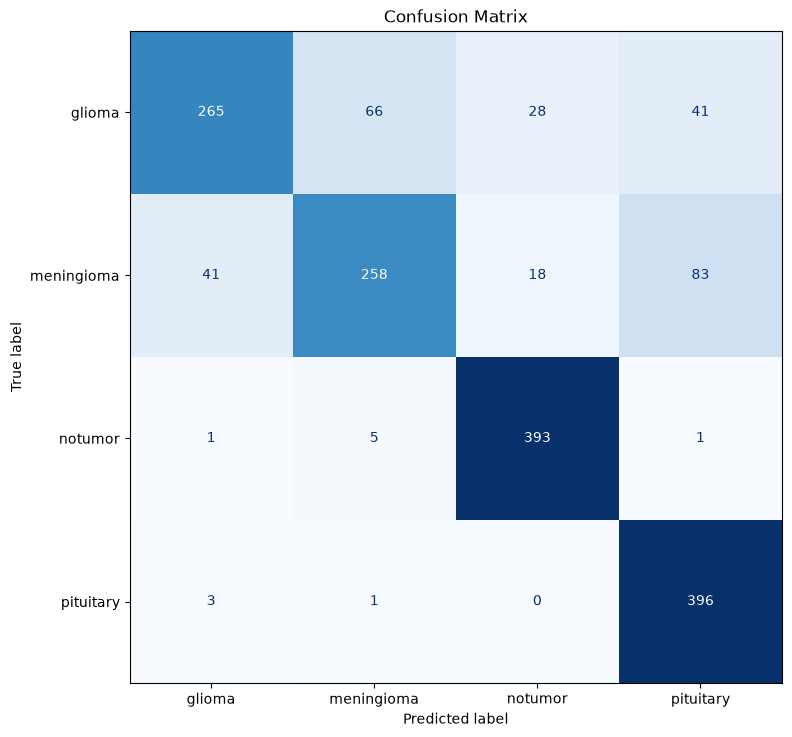

In [14]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

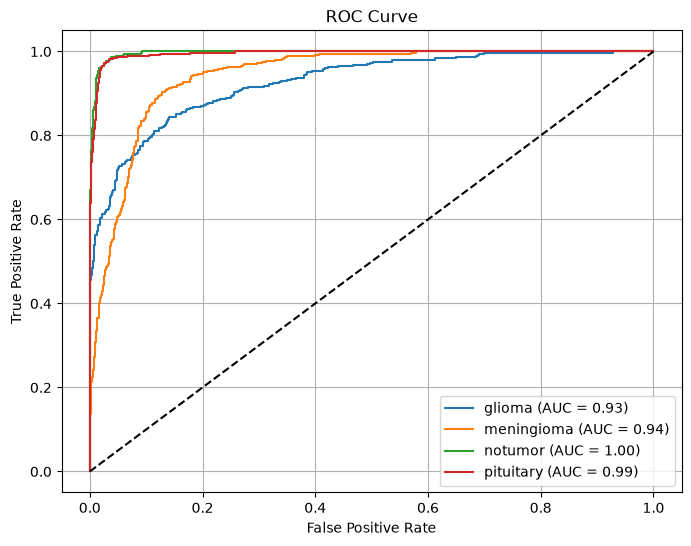

In [15]:
# ROC Curve

y_true_bin = label_binarize(
    y_true,
    classes=range(NUM_CLASSES)
)

plt.figure(figsize=(8,6))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        predictions[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{CLASS_NAMES[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.savefig(
    REPORTS_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# Load Test Images

test_images = []
test_labels = []

for images, labels in test_dataset:

    test_images.append(images.numpy())

    test_labels.append(
        np.argmax(labels.numpy(), axis=1)
    )

test_images = np.concatenate(test_images)

test_labels = np.concatenate(test_labels)

print(test_images.shape)

(1600, 224, 224, 3)


In [17]:
# Misclassified Images

wrong = np.where(y_true != y_pred)[0]

print(f"Total Misclassified : {len(wrong)}")

Total Misclassified : 288


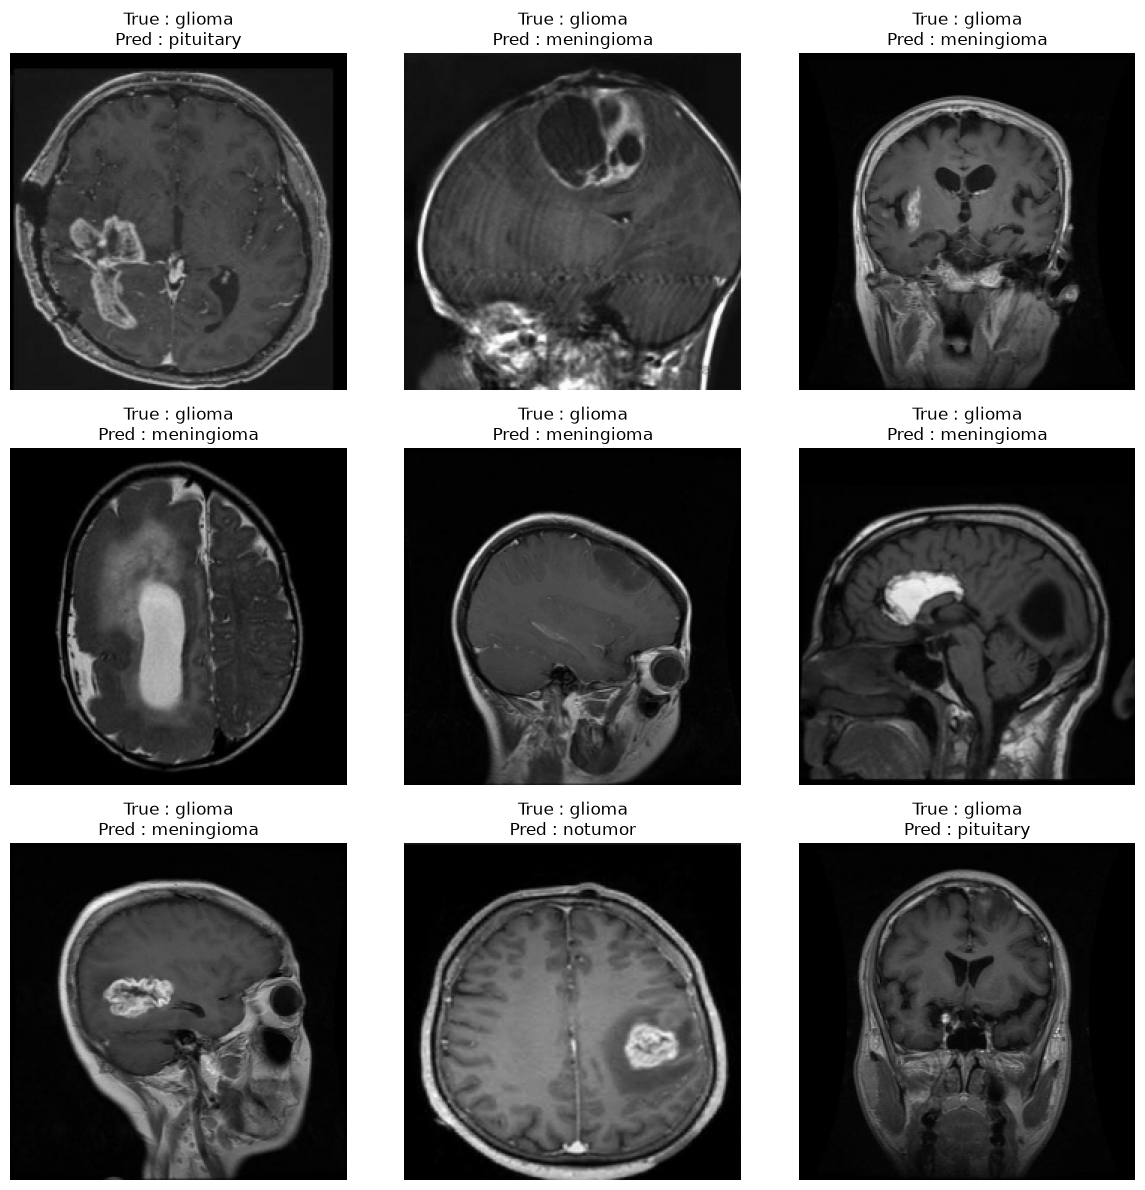

In [18]:
# Display Misclassified Images

plt.figure(figsize=(12,12))

for i, index in enumerate(wrong[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(test_images[index].astype("uint8"))

    plt.title(
        f"True : {CLASS_NAMES[y_true[index]]}\n"
        f"Pred : {CLASS_NAMES[y_pred[index]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [19]:
# Save Evaluation Metrics

metrics = {

    "accuracy": accuracy,

    "precision": precision,

    "recall": recall,

    "f1_score": f1

}

metrics

{'accuracy': 0.82,
 'precision': 0.8229875169596562,
 'recall': 0.82,
 'f1_score': 0.8125231501817334}

In [20]:
# Save Metrics

metrics_path = REPORTS_DIR / "metrics.pkl"

with open(metrics_path, "wb") as file:

    pickle.dump(metrics, file)

print("Metrics Saved Successfully")

Metrics Saved Successfully


In [21]:
# Final Evaluation Summary

print("=" * 60)

print("Model Evaluation Completed")

print("=" * 60)

print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")

print("=" * 60)

print("Generated Files")

print("classification_report.txt")
print("confusion_matrix.png")
print("roc_curve.png")
print("metrics.pkl")

print("=" * 60)

Model Evaluation Completed
Accuracy      : 0.8200
Precision     : 0.8230
Recall        : 0.8200
F1 Score      : 0.8125
Generated Files
classification_report.txt
confusion_matrix.png
roc_curve.png
metrics.pkl
